<a href="https://colab.research.google.com/github/saaraf1235-bot/Task17-Assignment17/blob/main/Task17_Assignment17.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Q1. Load the Heart Disease dataset using pandas and display the first 10 rows.
Also check the shape and basic information (info()) of the dataset.

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
uploaded = files.upload()

df = pd.read_csv("heart - heart.csv")
print(df.head(10))
print("Shape:")
print(df.shape)
print("\nBasic information of the dataset:")
print(df.info())


Saving heart - heart.csv to heart - heart (4).csv
   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   
5   39   M           NAP        120          339          0     Normal    170   
6   45   F           ATA        130          237          0     Normal    170   
7   54   M           ATA        110          208          0     Normal    142   
8   37   M           ASY        140          207          0     Normal    130   
9   48   F           ATA        120          284          0     Normal    120   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0      

Q2. Check for missing values in the dataset. Show the count of null values for
each column.

In [7]:
print("Count of null values for each column:")
print(df.isnull().sum())

Count of null values for each column:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


Q3. Check for duplicate rows in the dataset. If any duplicates are found, remove
them and print the new shape of the dataset.

In [10]:
duplicated_count = df.duplicated().sum()
print("Number of duplicated rows:",duplicated_count)

if duplicated_count > 0:
  df = df.drop_duplicates()
  print("Duplicates removed")
else:
  print("No duplicates row found")

print("New shape of dataset:",df.shape)

Number of duplicated rows: 0
No duplicates row found
New shape of dataset: (918, 12)


Q4. Identify unrealistic/invalid values:
Count how many rows have Cholesterol = 0.
Count how many rows have RestingBP = 0.
Print both counts.

In [14]:
chole = (df['Cholesterol'] == 0).sum()
print("Rows with cholesterol =0:",chole)
rest_BP = (df['RestingBP'] ==0).sum()
print("Rows with RestingBP =0:",rest_BP)

Rows with cholesterol =0: 172
Rows with RestingBP =0: 1


Q5. Clean the invalid values:
Replace Cholesterol = 0 with the mean cholesterol value (excluding zeros).
Replace RestingBP = 0 with the mean resting blood pressure value (excluding
zeros).
Round both columns to 2 decimal places.
Print the statistical summary (describe()) of these two columns before and after
cleaning.

In [23]:
print(df[['Cholesterol','RestingBP']].describe().round(2))
mean_chol = df.loc[df['Cholesterol'] > 0, 'Cholesterol'].mean()
df.loc[df['Cholesterol'] == 0, 'Cholesterol'] = mean_chol

mean_bp = df.loc[df['RestingBP'] > 0, 'RestingBP'].mean()
df.loc[df['RestingBP'] == 0, 'RestingBP'] = mean_bp

df[['Cholesterol','RestingBP']] = df[['Cholesterol','RestingBP']].round(2)
print("\nAfter Cleaning")
print(df[['Cholesterol','RestingBP']].describe().round(2))


       Cholesterol  RestingBP
count       918.00     918.00
mean        244.64     132.40
std          53.32      18.51
min          85.00       0.00
25%         214.00     120.00
50%         244.64     130.00
75%         267.00     140.00
max         603.00     200.00

After Cleaning
       Cholesterol  RestingBP
count       918.00     918.00
mean        244.64     132.54
std          53.32      17.99
min          85.00      80.00
25%         214.00     120.00
50%         244.64     130.00
75%         267.00     140.00
max         603.00     200.00


/tmp/ipykernel_1082/4207902061.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '132.54089422028352' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df['RestingBP'] == 0, 'RestingBP'] = mean_bp


Q6. Create a function to plot histograms for the following numerical columns:
Age
RestingBP
Cholesterol
MaxHR
Plot all four histograms in one figure using subplots (2x2 layout). Use this function
to visualize the data after cleaning.

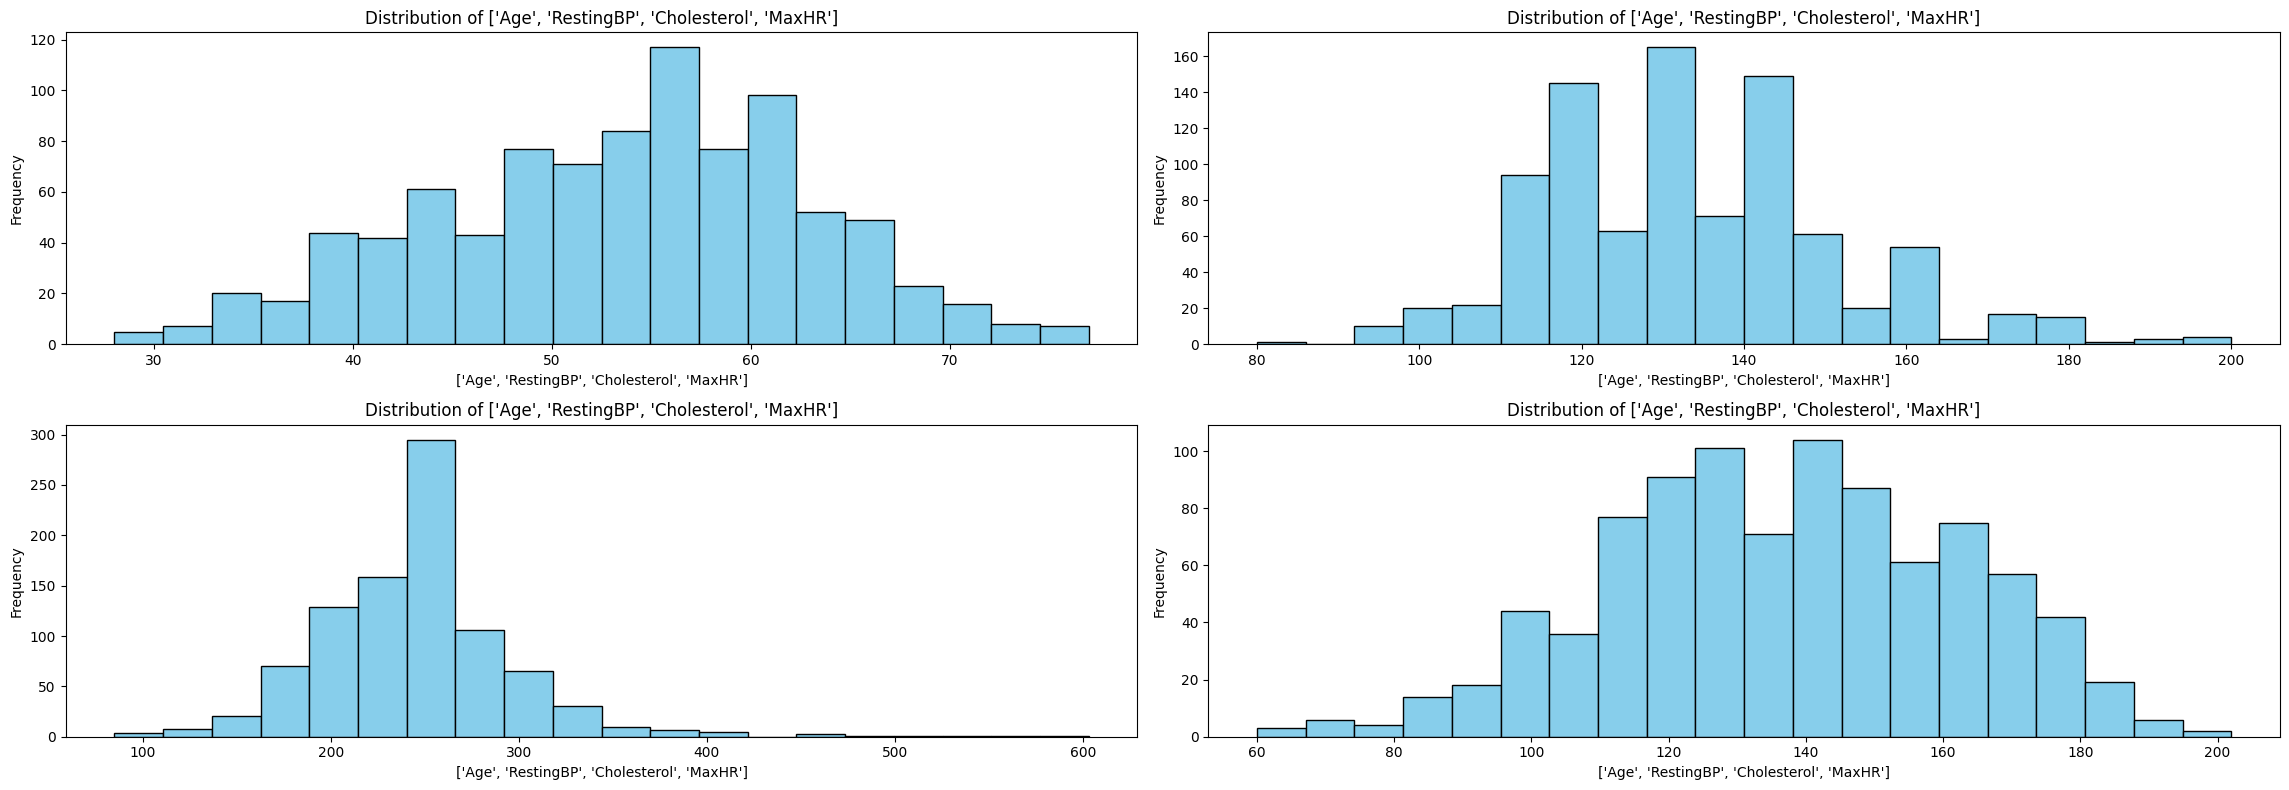

In [28]:
def plot_histo(df):
  columns = ["Age","RestingBP","Cholesterol","MaxHR"]

  fig,axes = plt.subplots(2,2,figsize=(23,8))
  axes = axes.flatten()

  for i,col in enumerate(columns):
    axes[i].hist(df[col], bins=20, color='skyblue', edgecolor='black')
    axes[i].set_title(f'Distribution of {columns}')
    axes[i].set_xlabel(columns)
    axes[i].set_ylabel('Frequency')
  plt.tight_layout()
  plt.show()
df_cleaned = df.dropna()
plot_histo(df_cleaned)


Q7. Identify and print numerical columns and categorical columns separately.

In [30]:
numerical_col = df.select_dtypes(include=['int64','float64']).columns.tolist()
print("Numerical columns:",numerical_col)
categorical_col = df.select_dtypes(include=['object']).columns.tolist()
print("Categorical columns:",categorical_col)

Numerical columns: ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'HeartDisease']
Categorical columns: ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']


Q8. Perform One-Hot Encoding on all categorical columns using
pd.get_dummies().
Store the result in a new dataframe called df_encoded.
Print the shape and the first 5 rows of the encoded dataframe.

In [31]:
categorical_col = df.select_dtypes(include=['object']).columns.tolist()
encoded_df = pd.get_dummies(df, columns=categorical_col, drop_first=True)
print("Shape of encoded dataframe:",encoded_df.shape)
print("\nFirst 5 rows:")
print(df.head())

Shape of encoded dataframe: (918, 16)

First 5 rows:
   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA      140.0        289.0          0     Normal    172   
1   49   F           NAP      160.0        180.0          0     Normal    156   
2   37   M           ATA      130.0        283.0          0         ST     98   
3   48   F           ASY      138.0        214.0          0     Normal    108   
4   54   M           NAP      150.0        195.0          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0       Up             0  


Q9. After cleaning and encoding:
Print the final shape of df_encoded.
Show the list of all column names in the final dataframe.

In [33]:
print("Final shape:",encoded_df.shape)
print("\nList of all columns:",encoded_df.columns)

Final shape: (918, 16)

List of all columns: Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease', 'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP',
       'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST',
       'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype='object')


Q10. (Summary)
Write a short summary (in comments or markdown) covering:
1. What invalid values did you find and how did you fix them?
2. Why is it important to handle invalid values like Cholesterol = 0?
3. What is the purpose of One-Hot Encoding?
4. Any other observations from the cleaning process.

In [ ]:
""" Summary of Data Cleaning and Encoding

1)I found Cholestrol =0 and RestingBP =   0.
I have replaced them with the mean of that column.

2) 0 is not medically possible. It will disort mean,plots,and ML model accuracy.

3)To convert text categorical columns into 0/1 numeric columns so ML models can
use them.

4)Shape changed from (918,11) to (918,16). After encoding, all columns are numeric
and ready for ML.
"""